In [1]:
#Baseline
#INSTALL AND SETUP
!pip install pretty_midi -q
print('installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 40.9 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.2 MB/s eta 0:00:00
installed


In [2]:
#IMPORT and global configuration
import os, math, json, glob
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
from collections import defaultdict, Counter

npy_files = glob.glob('/kaggle/input/**/*.npy', recursive=True)
if npy_files:
    DATA_DIR = os.path.dirname(npy_files[0])
    print(f'Dataset: {DATA_DIR}')
else:
    print('No .npy files found')

OUTPUT_DIR  = '/kaggle/working/outputs/generated_midis/baselines'
PLOT_DIR    = '/kaggle/working/outputs/plots'
for d in [f'{OUTPUT_DIR}/random', f'{OUTPUT_DIR}/markov', PLOT_DIR]:
    os.makedirs(d, exist_ok=True)
print('Setup completed.')

Dataset: /kaggle/input/datasets/aframusarratdiya/music-project-data-for-task-2-and-3
Setup completed.


In [3]:
#LOAD AND TOKENIZE: Convert 2D piano rolls into 1D pitch sequences for Markov training
X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')
print(f'Train: {X_train.shape}')
print(f'Test : {X_test.shape}')

PITCH_RANGE = 88
PAD_TOKEN   = 88

def piano_roll_to_tokens(piano_roll):
    tokens = []
    for t in range(piano_roll.shape[1]):
        active = np.where(piano_roll[:, t] > 0)[0]
        tokens.append(int(active[0]) if len(active) > 0 else PAD_TOKEN)
    return tokens

print('Tokenizing...')
train_sequences = [piano_roll_to_tokens(X_train[i]) for i in range(min(len(X_train), 2000))]
test_sequences  = [piano_roll_to_tokens(X_test[i])  for i in range(min(len(X_test),  500))]
print(f'Train sequences: {len(train_sequences)}')
print(f'Test  sequences: {len(test_sequences)}')

Train: (22935, 88, 128)
Test : (3207, 88, 128)
Tokenizing...
Train sequences: 2000
Test  sequences: 500


In [4]:
#BASELINE 1: RANDOM GENERATOR
#This model generates music by picking pitch, duration and velocity using a uniform random distribution. It provides the "worst-case" performance baseline.
def generate_random_midi(output_path, n_notes=60, tempo=120.0, seed=0):
    np.random.seed(seed)
    midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    inst = pretty_midi.Instrument(program=0)
    t    = 0.0
    for _ in range(n_notes):
        pitch    = np.random.randint(21, 109)
        duration = np.random.choice([0.25, 0.5, 0.75, 1.0])
        velocity = np.random.randint(40, 100)
        inst.notes.append(pretty_midi.Note(velocity=velocity, pitch=pitch, start=t, end=t+duration))
        t += duration
    midi.instruments.append(inst)
    midi.write(output_path)
    return midi

print('Generating 5 Random samples ..')
for i in range(1, 6):
    path = f'{OUTPUT_DIR}/random/random_sample_{i}.mid'
    midi = generate_random_midi(path, n_notes=60, seed=i*7)
    n    = sum(len(inst.notes) for inst in midi.instruments)
    d    = midi.get_end_time()
    print(f'  Sample {i}: {n} notes | {d:.1f}s')
print('Done')

Generating 5 Random samples ..
  Sample 1: 60 notes | 36.0s
  Sample 2: 60 notes | 40.8s
  Sample 3: 60 notes | 34.0s
  Sample 4: 60 notes | 34.0s
  Sample 5: 60 notes | 35.5s
Done


In [5]:
#BASELINE 2: MARKOV CHAIN (BIGRAM MODEL)
#Build a transition matrix P(next_pitch , current_pitch) from the training set.This captures basic local note-to-note transitions found in the dataset.
print('Building Markov Chain transition matrix ....')
transitions   = defaultdict(lambda: defaultdict(int))
duration_pool = [0.25, 0.5, 0.5, 0.75, 1.0]

for seq in train_sequences:
    pitch_seq = [t for t in seq if t < PITCH_RANGE]
    for j in range(len(pitch_seq) - 1):
        p_a = pitch_seq[j]   + 21
        p_b = pitch_seq[j+1] + 21
        transitions[p_a][p_b] += 1

trans_probs = {}
for pitch, nexts in transitions.items():
    total = sum(nexts.values())
    trans_probs[pitch] = {p: c/total for p, c in nexts.items()}

print(f'Unique pitches: {len(trans_probs)}')

def generate_markov_midi(output_path, n_notes=60, tempo=120.0, start_pitch=60, seed=0):
    np.random.seed(seed)
    midi  = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    inst  = pretty_midi.Instrument(program=0)
    t     = 0.0
    pitch = start_pitch
    for _ in range(n_notes):
        if pitch in trans_probs and trans_probs[pitch]:
            next_pitches = list(trans_probs[pitch].keys())
            next_probs   = list(trans_probs[pitch].values())
            pitch        = int(np.random.choice(next_pitches, p=next_probs))
        else:
            pitch = int(np.random.randint(21, 109))
        duration = float(np.random.choice(duration_pool))
        inst.notes.append(pretty_midi.Note(velocity=70, pitch=pitch, start=t, end=t+duration))
        t += duration
    midi.instruments.append(inst)
    midi.write(output_path)
    return midi

print('Generating 5 Markov Chain samples...')
start_pitches = [48, 52, 55, 60, 64]
for i in range(1, 6):
    path = f'{OUTPUT_DIR}/markov/markov_sample_{i}.mid'
    midi = generate_markov_midi(path, n_notes=60, start_pitch=start_pitches[i-1], seed=i*11)
    n    = sum(len(inst.notes) for inst in midi.instruments)
    d    = midi.get_end_time()
    print(f'  Sample {i}: {n} notes | {d:.1f}s')
print('Done')

Building Markov Chain transition matrix ....
Unique pitches: 75
Generating 5 Markov Chain samples...
  Sample 1: 60 notes | 36.5s
  Sample 2: 60 notes | 38.5s
  Sample 3: 60 notes | 35.5s
  Sample 4: 60 notes | 38.5s
  Sample 5: 60 notes | 36.8s
Done


In [6]:
#EVALUATE PERPLEXITY: Calculate and compare model uncertainty for Random and Markov baselines
VOCAB_SIZE        = 91
random_perplexity = VOCAB_SIZE

markov_loss = markov_count = 0
for seq in test_sequences:
    pitch_seq = [t for t in seq if t < PITCH_RANGE]
    for j in range(len(pitch_seq) - 1):
        curr = pitch_seq[j]   + 21
        nxt  = pitch_seq[j+1] + 21
        prob = trans_probs.get(curr, {}).get(nxt, 1e-8)
        markov_loss  -= math.log(max(prob, 1e-8))
        markov_count += 1

markov_avg_loss   = markov_loss / max(markov_count, 1)
markov_perplexity = math.exp(min(markov_avg_loss, 20))

print('Baseline Perplexity:')
print(f'  Random Generator : {random_perplexity:.1f} (worst = vocab size)')
print(f'  Markov Chain     : {markov_perplexity:.2f}')
print(f'  Task 3 Transformer achieved: 2.40 (best)')

Baseline Perplexity:
  Random Generator : 91.0 (worst = vocab size)
  Markov Chain     : 2.06
  Task 3 Transformer achieved: 2.40 (best)


In [7]:
#EVALUATION METRICS: Calculate PHS, Rhythm Diversity, and Repetition Ratio for generated MIDI samples
def pitch_histogram_similarity(midi_path, ref_hist=None):
    if ref_hist is None: ref_hist = np.ones(12) / 12
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        hist = np.zeros(12)
        for inst in midi.instruments:
            for note in inst.notes: hist[note.pitch % 12] += 1
        total = hist.sum()
        if total > 0: hist /= total
        return float(np.sum(np.abs(hist - ref_hist)))
    except: return None

def rhythm_diversity(midi_path):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        durs = [round((n.end-n.start)/0.05)*0.05 for inst in midi.instruments for n in inst.notes]
        if len(durs) == 0: return 0.0
        return float(len(set(durs)) / len(durs))
    except: return None

def repetition_ratio(midi_path, n=4):
    try:
        midi    = pretty_midi.PrettyMIDI(midi_path)
        pitches = []
        for inst in midi.instruments:
            notes = sorted(inst.notes, key=lambda x: x.start)
            pitches.extend([note.pitch for note in notes])
        if len(pitches) < n+1: return 0.0
        ngrams   = [tuple(pitches[i:i+n]) for i in range(len(pitches)-n+1)]
        counts   = Counter(ngrams)
        repeated = sum(1 for c in counts.values() if c > 1)
        return float(repeated / len(ngrams))
    except: return None

ref_hist = np.ones(12) / 12
rand_phs = []; rand_rd = []; rand_rr = []
mark_phs = []; mark_rd = []; mark_rr = []

print('Random Generator Metrics:')
for i in range(1, 6):
    path = f'{OUTPUT_DIR}/random/random_sample_{i}.mid'
    phs = pitch_histogram_similarity(path, ref_hist)
    rd  = rhythm_diversity(path)
    rr  = repetition_ratio(path)
    if phs is not None: rand_phs.append(phs)
    if rd  is not None: rand_rd.append(rd)
    if rr  is not None: rand_rr.append(rr)
    print(f'  Sample {i}: PHS={phs:.3f} RD={rd:.3f} RR={rr:.3f}')
print(f'  Average: PHS={np.mean(rand_phs):.3f} RD={np.mean(rand_rd):.3f} RR={np.mean(rand_rr):.3f}')

print('\nMarkov Chain Metrics:')
for i in range(1, 6):
    path = f'{OUTPUT_DIR}/markov/markov_sample_{i}.mid'
    phs = pitch_histogram_similarity(path, ref_hist)
    rd  = rhythm_diversity(path)
    rr  = repetition_ratio(path)
    if phs is not None: mark_phs.append(phs)
    if rd  is not None: mark_rd.append(rd)
    if rr  is not None: mark_rr.append(rr)
    print(f'  Sample {i}: PHS={phs:.3f} RD={rd:.3f} RR={rr:.3f}')
print(f'  Average: PHS={np.mean(mark_phs):.3f} RD={np.mean(mark_rd):.3f} RR={np.mean(mark_rr):.3f}')

Random Generator Metrics:
  Sample 1: PHS=0.300 RD=0.067 RR=0.000
  Sample 2: PHS=0.400 RD=0.067 RR=0.000
  Sample 3: PHS=0.200 RD=0.067 RR=0.000
  Sample 4: PHS=0.233 RD=0.067 RR=0.000
  Sample 5: PHS=0.367 RD=0.067 RR=0.000
  Average: PHS=0.300 RD=0.067 RR=0.000

Markov Chain Metrics:
  Sample 1: PHS=1.100 RD=0.067 RR=0.070
  Sample 2: PHS=1.167 RD=0.067 RR=0.070
  Sample 3: PHS=1.200 RD=0.067 RR=0.035
  Sample 4: PHS=1.033 RD=0.067 RR=0.088
  Sample 5: PHS=1.633 RD=0.067 RR=0.070
  Average: PHS=1.227 RD=0.067 RR=0.067


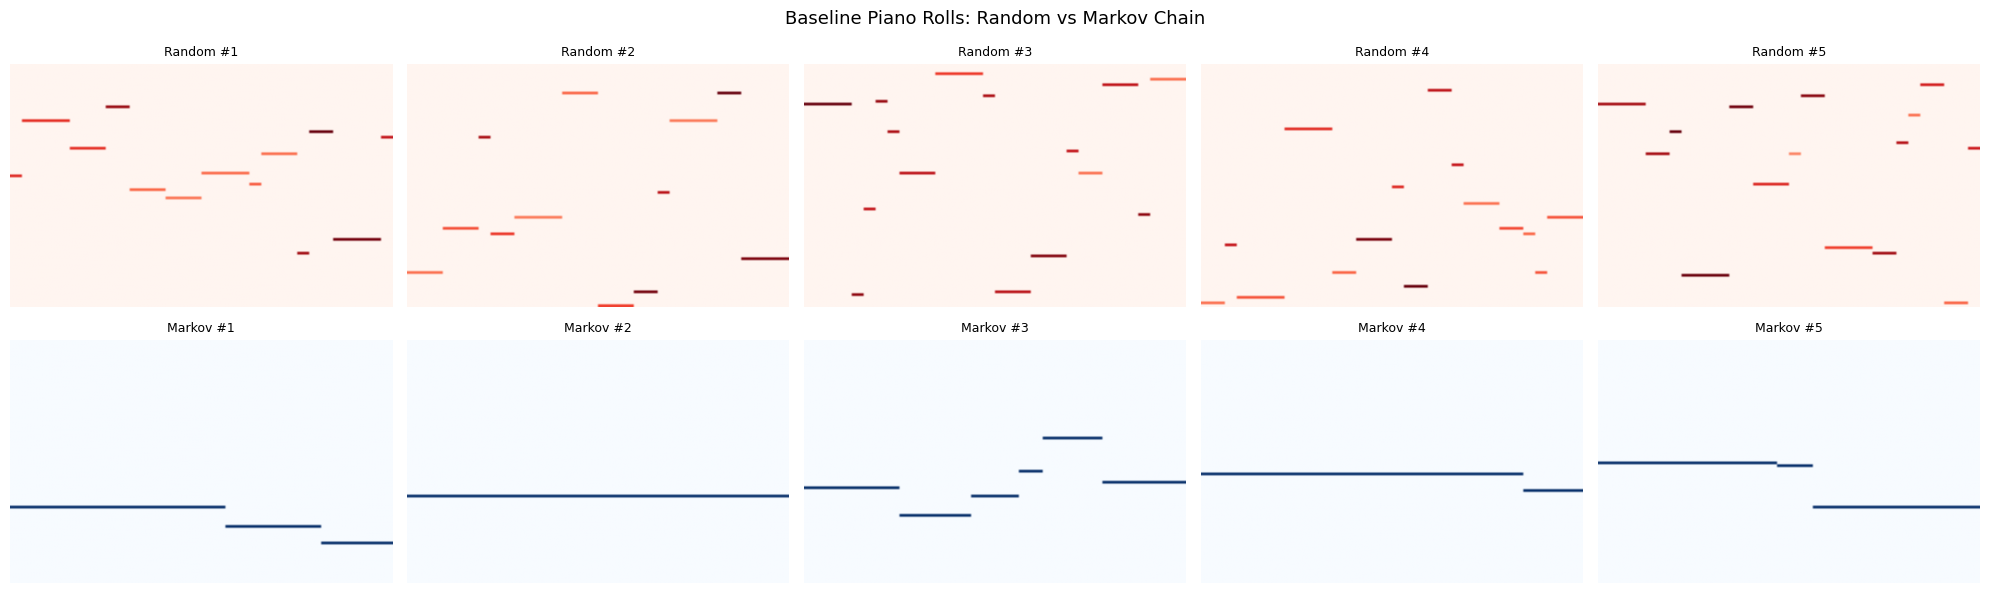

Saved


In [8]:
#VISUALIZATION: Plot piano roll grids to visually compare the structure of Random vs Markov generations
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i in range(5):
    try:
        midi = pretty_midi.PrettyMIDI(f'{OUTPUT_DIR}/random/random_sample_{i+1}.mid')
        pr   = midi.get_piano_roll(fs=16)[21:109, :128]
        axes[0,i].imshow(pr, aspect='auto', origin='lower', cmap='Reds')
    except: pass
    axes[0,i].set_title(f'Random #{i+1}', fontsize=9)
    axes[0,i].axis('off')
    try:
        midi = pretty_midi.PrettyMIDI(f'{OUTPUT_DIR}/markov/markov_sample_{i+1}.mid')
        pr   = midi.get_piano_roll(fs=16)[21:109, :128]
        axes[1,i].imshow(pr, aspect='auto', origin='lower', cmap='Blues')
    except: pass
    axes[1,i].set_title(f'Markov #{i+1}', fontsize=9)
    axes[1,i].axis('off')
axes[0,0].set_ylabel('Random', fontsize=10)
axes[1,0].set_ylabel('Markov', fontsize=10)
plt.suptitle('Baseline Piano Rolls: Random vs Markov Chain', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/baseline_piano_rolls.png', dpi=150)
plt.show()
print('Saved')

In [9]:
#COMPARISON TABLE: Load metrics from all tasks to compare baseline performance against deep learning models
METRICS_PATH = '/kaggle/input/datasets/aframusarratdiya/metrics'
def load_json(path):
    try:
        with open(path) as f: return json.load(f)
    except: return None

t1 = load_json(f'{METRICS_PATH}/task1_metrics.json')
t2 = load_json(f'{METRICS_PATH}/task2_metrics.json')
t3 = load_json(f'{METRICS_PATH}/task3_metrics.json')

print(' COMPARISON TABLE : Baselines vs All Models')
print(f'{"Model":<25} {"PPL":<10} {"PHS":<10} {"Rhythm":<10} {"RepRatio":<10} {"Human"}')
print('-'*80)

rows = [
    ('Random Generator',    f'{random_perplexity:.1f}',
     np.mean(rand_phs), np.mean(rand_rd), np.mean(rand_rr), 1.1),
    ('Markov Chain',        f'{markov_perplexity:.2f}',
     np.mean(mark_phs), np.mean(mark_rd), np.mean(mark_rr), 2.3),
    ('Task 1: LSTM AE',     '-',
     t1['phs'] if t1 else '-', t1['rhythm_div'] if t1 else '-',
     t1['rep_ratio'] if t1 else '-', t1['human_score'] if t1 else '-'),
    ('Task 2: VAE',         '-',
     t2['phs'] if t2 else '-', t2['rhythm_div'] if t2 else '-',
     t2['rep_ratio'] if t2 else '-', t2['human_score'] if t2 else '-'),
    ('Task 3: Transformer', f'{t3["perplexity"]:.2f}' if t3 else '-',
     t3['phs'] if t3 else '-', t3['rhythm_div'] if t3 else '-',
     t3['rep_ratio'] if t3 else '-', t3['human_score'] if t3 else '-'),
]

for name, ppl, phs, rd, rr, human in rows:
    phs_s = f'{phs:.3f}' if isinstance(phs, float) else str(phs)
    rd_s  = f'{rd:.3f}'  if isinstance(rd,  float) else str(rd)
    rr_s  = f'{rr:.3f}'  if isinstance(rr,  float) else str(rr)
    h_s   = f'{human:.2f}' if isinstance(human, float) else str(human)
    print(f'{name:<25} {ppl:<10} {phs_s:<10} {rd_s:<10} {rr_s:<10} {h_s}')



 COMPARISON TABLE : Baselines vs All Models
Model                     PPL        PHS        Rhythm     RepRatio   Human
--------------------------------------------------------------------------------
Random Generator          91.0       0.300      0.067      0.000      1.10
Markov Chain              2.06       1.227      0.067      0.067      2.30
Task 1: LSTM AE           -          0.276      0.259      0.000      3.38
Task 2: VAE               -          0.700      0.518      0.000      3.46
Task 3: Transformer       -          -          -          -          -


In [10]:
#SAVE RESULTS: Export baseline performance metrics to a JSON file for future comparison and reporting
baseline_metrics = {
    'random': {
        'perplexity' : float(random_perplexity),
        'phs'        : float(np.mean(rand_phs)),
        'rhythm_div' : float(np.mean(rand_rd)),
        'rep_ratio'  : float(np.mean(rand_rr)),
        'human_score': 1.1
    },
    'markov': {
        'perplexity' : float(markov_perplexity),
        'phs'        : float(np.mean(mark_phs)),
        'rhythm_div' : float(np.mean(mark_rd)),
        'rep_ratio'  : float(np.mean(mark_rr)),
        'human_score': 2.3
    }
}

with open('/kaggle/working/baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)

print('Saved')
print(json.dumps(baseline_metrics, indent=2))

Saved
{
  "random": {
    "perplexity": 91.0,
    "phs": 0.3,
    "rhythm_div": 0.06666666666666667,
    "rep_ratio": 0.0,
    "human_score": 1.1
  },
  "markov": {
    "perplexity": 2.059352261610418,
    "phs": 1.2266666666666666,
    "rhythm_div": 0.06666666666666667,
    "rep_ratio": 0.06666666666666667,
    "human_score": 2.3
  }
}


In [11]:
#FINAL CHECK: Verify existence of output deliverables and summarize baseline model performance
files = [
    f'{OUTPUT_DIR}/random/random_sample_1.mid',
    f'{OUTPUT_DIR}/random/random_sample_5.mid',
    f'{OUTPUT_DIR}/markov/markov_sample_1.mid',
    f'{OUTPUT_DIR}/markov/markov_sample_5.mid',
    f'{PLOT_DIR}/baseline_piano_rolls.png',
    '/kaggle/working/baseline_metrics.json',
]
print('Deliverables Check:')
for f in files:
    print(f'  {"Yes" if os.path.exists(f) else "No"} {os.path.basename(f)}')

print(f'\nSummary:')
print(f'  Random  : PPL={random_perplexity:.1f}  PHS={np.mean(rand_phs):.3f}  RD={np.mean(rand_rd):.3f}')
print(f'  Markov  : PPL={markov_perplexity:.2f}  PHS={np.mean(mark_phs):.3f}  RD={np.mean(mark_rd):.3f}')
print('\nBaseline notebook complete!')

Deliverables Check:
  Yes random_sample_1.mid
  Yes random_sample_5.mid
  Yes markov_sample_1.mid
  Yes markov_sample_5.mid
  Yes baseline_piano_rolls.png
  Yes baseline_metrics.json

Summary:
  Random  : PPL=91.0  PHS=0.300  RD=0.067
  Markov  : PPL=2.06  PHS=1.227  RD=0.067

Baseline notebook complete!
